<a href="https://colab.research.google.com/github/SunitaJakhar/Breast-Cancer-Prediction-Using-Machine-Learning/blob/main/Breast_Cancer_Prediction_Using_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Breast Cancer Wisconsin (Diagnostic) Data Set

This project examines the role of machine learning in healthcare, with a focus on early disease prediction. It applies machine learning techniques to classify tumors as benign or malignant, using models such as Support Vector Machine (SVM) and XGBoost.


Task 1 - Dataset Loading, Data Preprocessing & Cleaning

In [ ]:
# Import Libraries - Pandas & Numpy
import pandas as pd
import numpy as np

In [ ]:
# Loading Dataset
df = pd.read_csv('/content/Breast Cancer Wisconsin (Diagnostic) Data Set.csv')

In [ ]:
df.head(5)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [ ]:
# Identify missing values:
df.isnull()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
565,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
566,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
567,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [ ]:
# Count missing values
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [ ]:
# Data Cleaning - Drop the 'Unnamed: 32' column as it contains all NaN values, and "id" as it is an identifier and not required in analysis.

if "Unnamed: 32" in df.columns:df = df.drop(columns=["Unnamed: 32"])
if "id" in df.columns:df = df.drop(columns=["id"])

In [ ]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
# Detect outliers using IQR
numerical_cols = df.select_dtypes(include=[np.number]).columns

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"{col}: {len(outliers)} outliers detected")

radius_mean: 14 outliers detected
texture_mean: 7 outliers detected
perimeter_mean: 13 outliers detected
area_mean: 25 outliers detected
smoothness_mean: 6 outliers detected
compactness_mean: 16 outliers detected
concavity_mean: 18 outliers detected
concave points_mean: 10 outliers detected
symmetry_mean: 15 outliers detected
fractal_dimension_mean: 15 outliers detected
radius_se: 38 outliers detected
texture_se: 20 outliers detected
perimeter_se: 38 outliers detected
area_se: 65 outliers detected
smoothness_se: 30 outliers detected
compactness_se: 28 outliers detected
concavity_se: 22 outliers detected
concave points_se: 19 outliers detected
symmetry_se: 27 outliers detected
fractal_dimension_se: 28 outliers detected
radius_worst: 17 outliers detected
texture_worst: 5 outliers detected
perimeter_worst: 15 outliers detected
area_worst: 35 outliers detected
smoothness_worst: 7 outliers detected
compactness_worst: 16 outliers detected
concavity_worst: 12 outliers detected
concave points_

In [ ]:
# Capping Outliers (Winsorization) - Using this to keep all records but reduce the influence of extreme values

df_capped = df.copy()
for col in numerical_cols:
    Q1 = df_capped[col].quantile(0.25)
    Q3 = df_capped[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_capped[col] = df_capped[col].clip(lower=lower_bound,
                                         upper=upper_bound)
print("Outliers have been capped.")

Outliers have been capped.


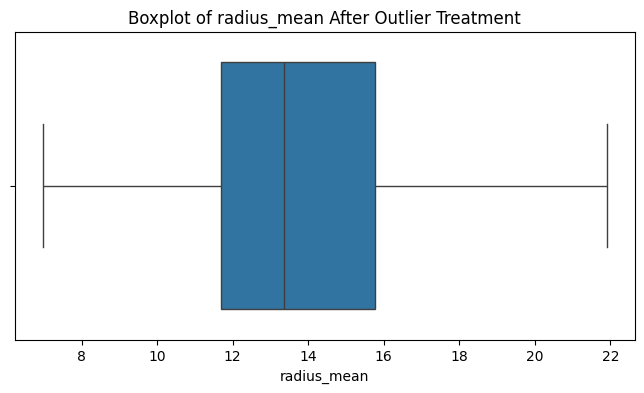

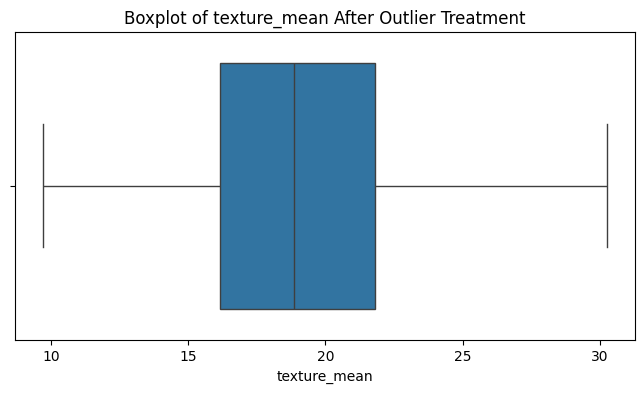

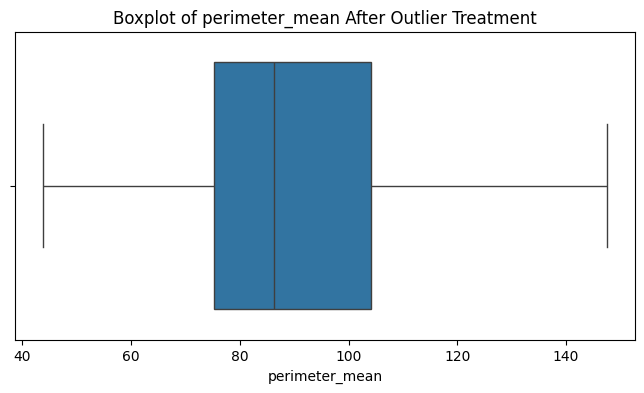

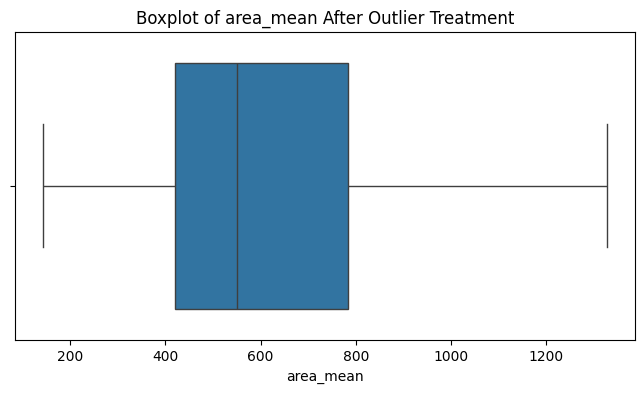

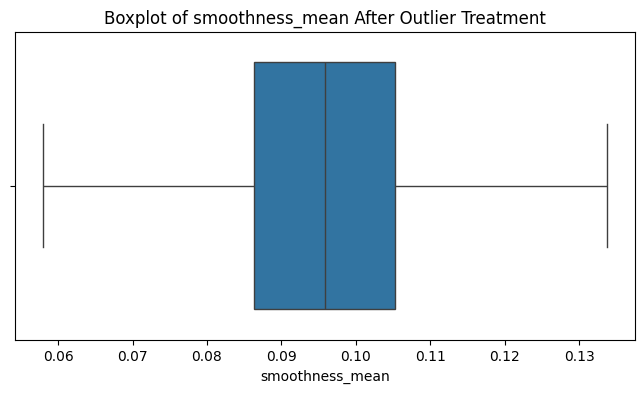

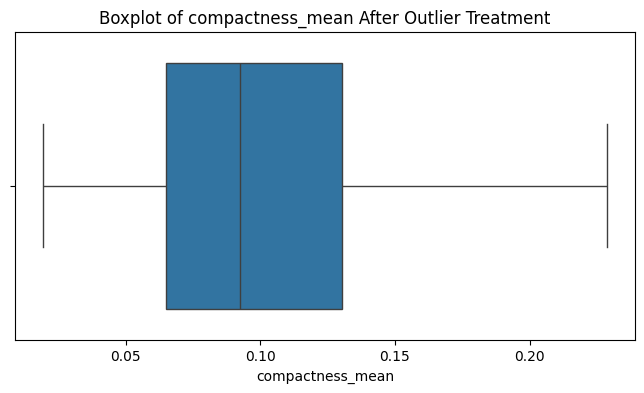

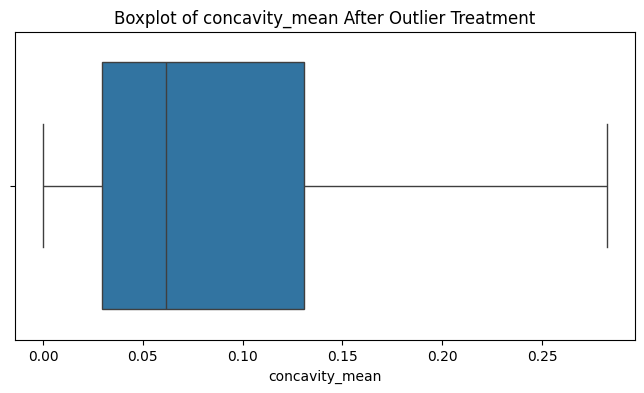

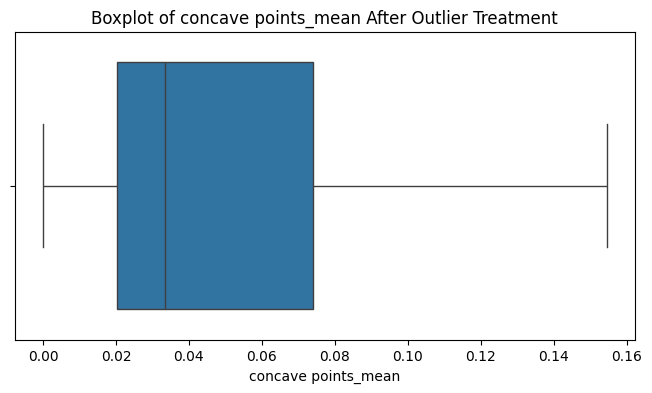

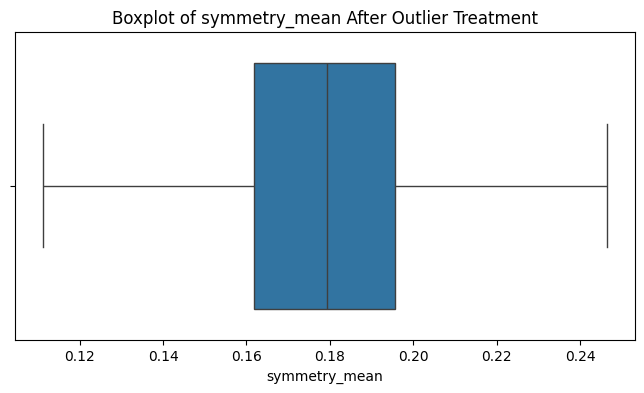

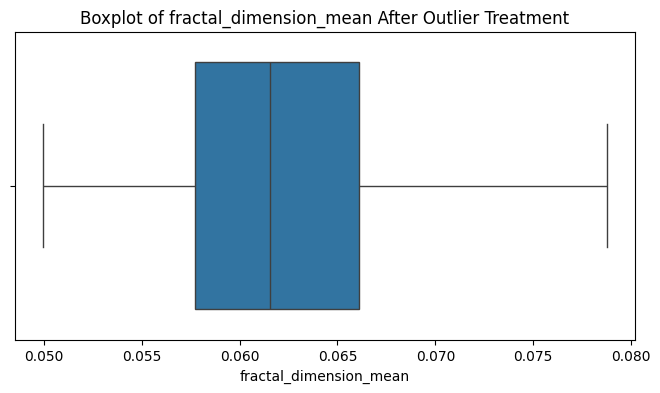

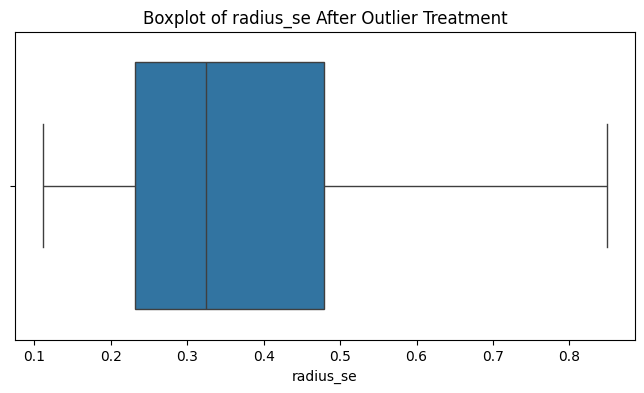

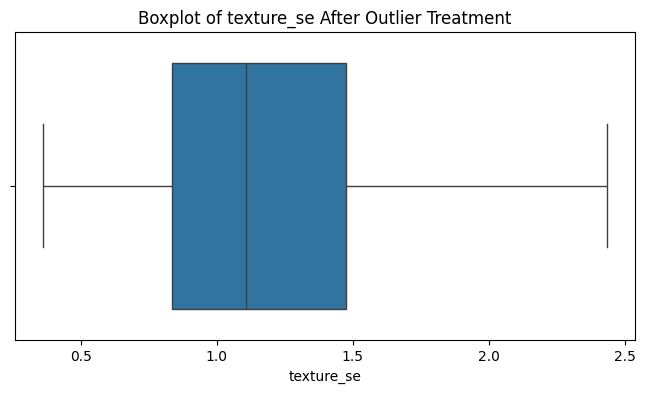

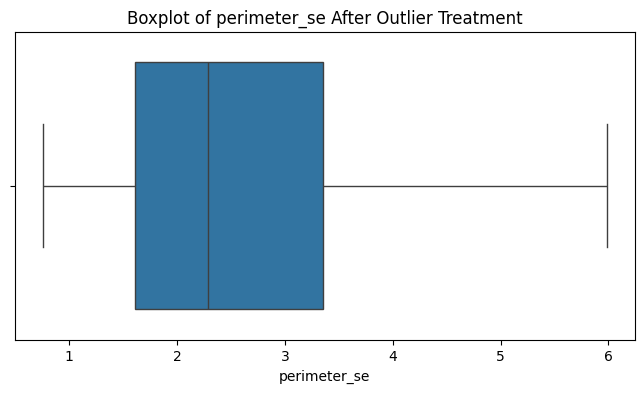

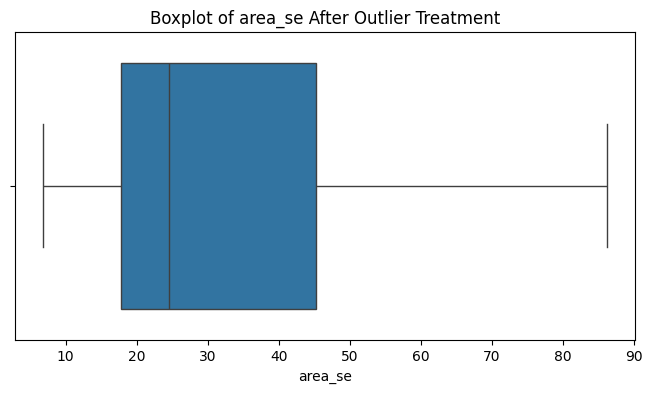

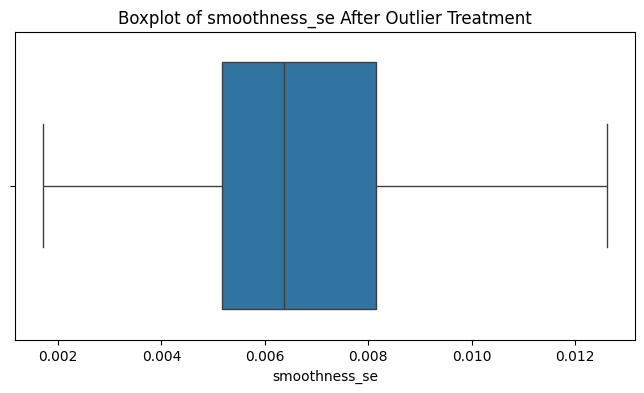

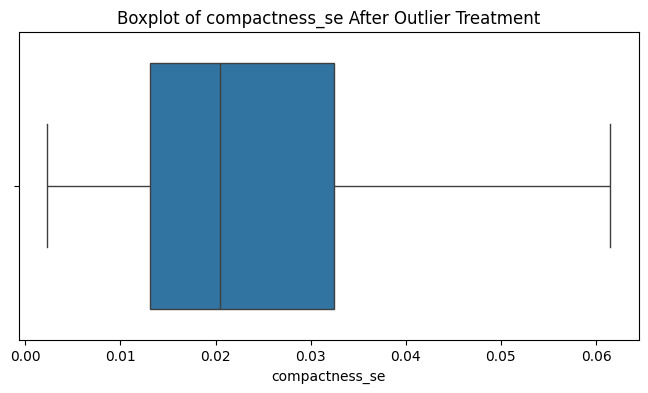

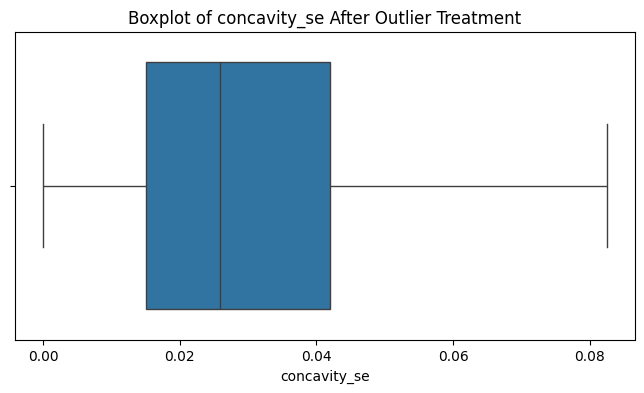

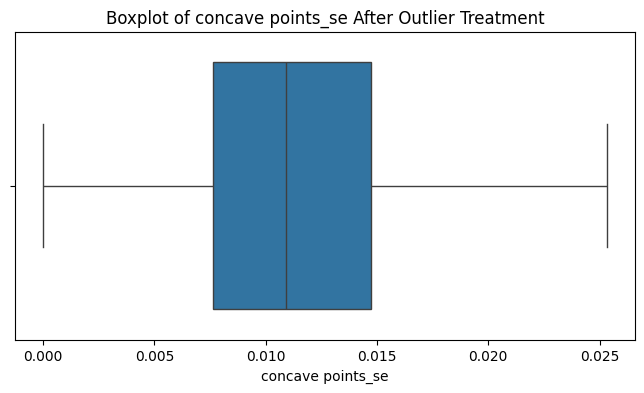

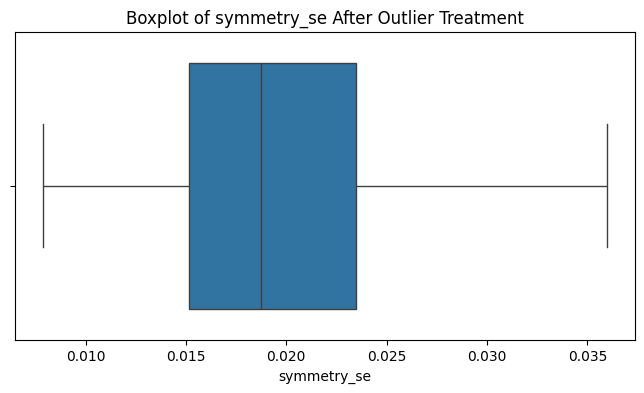

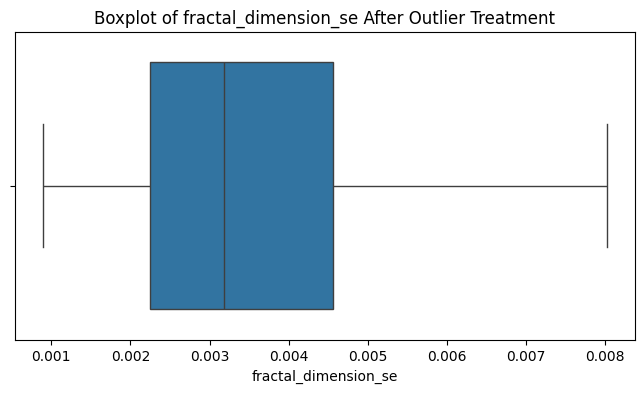

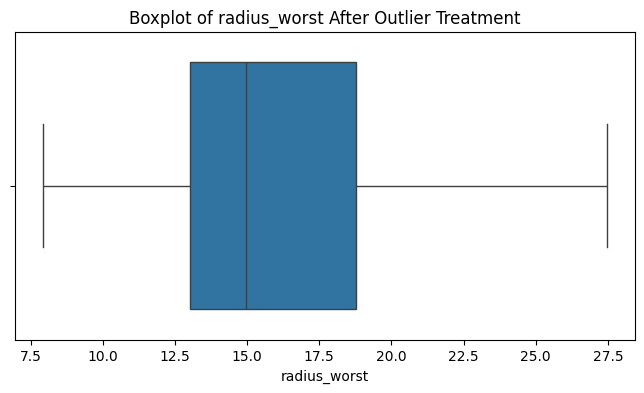

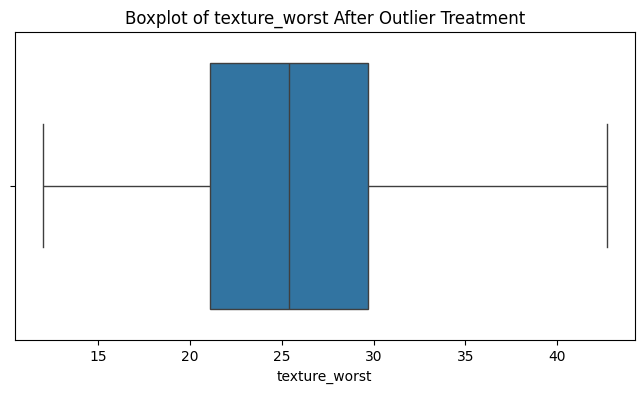

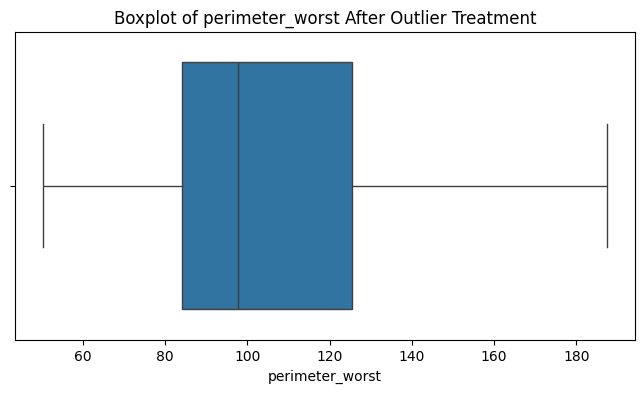

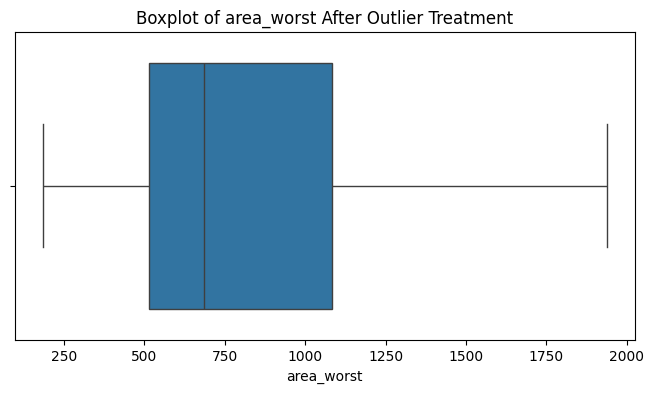

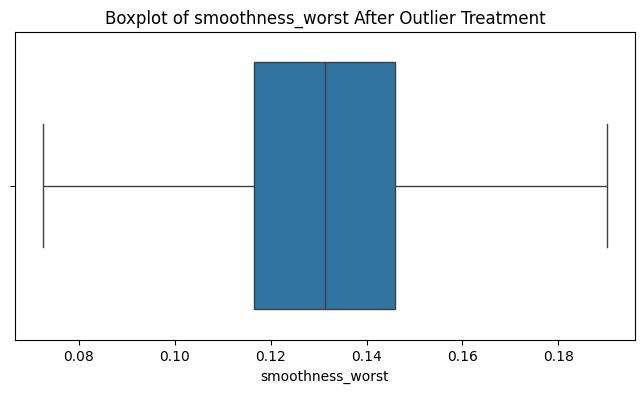

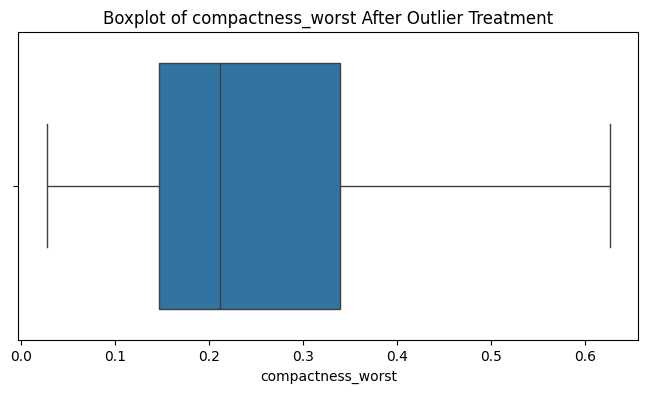

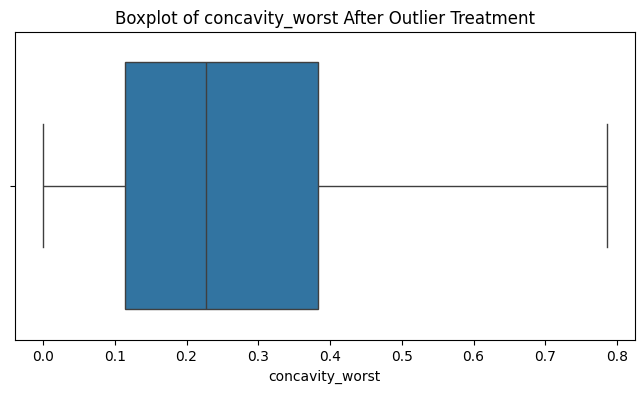

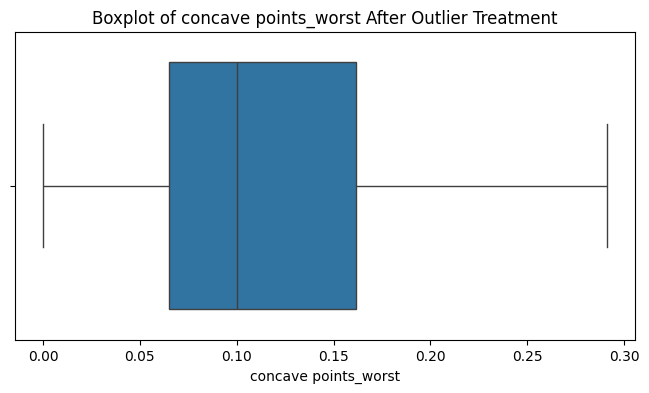

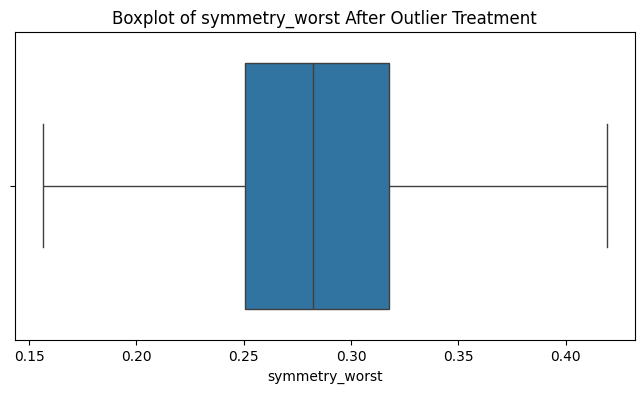

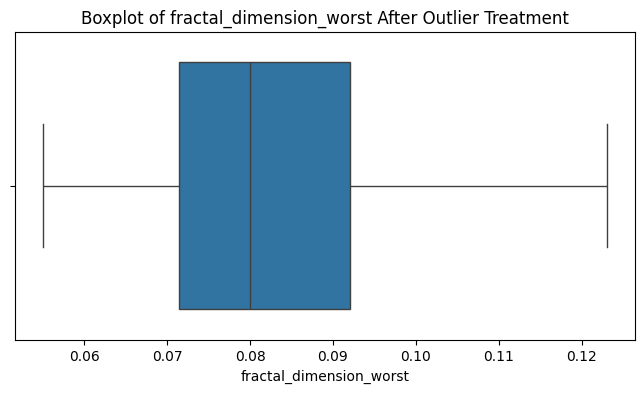

In [ ]:
# Verify the Treatment with New Boxplots

for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df_capped[col])  # or df_removed[col]
    plt.title(f'Boxplot of {col} After Outlier Treatment')
    plt.show()

In [ ]:
# Check missing/null values - o recheck and ensure there are no more null values present in the dataset.
df.isna().sum()

,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0
symmetry_mean,0


In [ ]:
# Encode target "diagnosis" - Object to Integer
df["diagnosis"] = df["diagnosis"].map({"B": 0, "M": 1}).astype(int)

In [ ]:
df.head(25)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.990,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.71190,0.26540,0.4601,0.11890
1,1,20.570,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.24160,0.18600,0.2750,0.08902
2,1,19.690,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.45040,0.24300,0.3613,0.08758
3,1,11.420,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.68690,0.25750,0.6638,0.17300
4,1,20.290,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.40000,0.16250,0.2364,0.07678
5,1,12.450,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.53550,0.17410,0.3985,0.12440
6,1,18.250,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,...,22.88,27.66,153.20,1606.0,0.1442,0.2576,0.37840,0.19320,0.3063,0.08368
7,1,13.710,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,...,17.06,28.14,110.60,897.0,0.1654,0.3682,0.26780,0.15560,0.3196,0.11510
8,1,13.000,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,...,15.49,30.73,106.20,739.3,0.1703,0.5401,0.53900,0.20600,0.4378,0.10720
9,1,12.460,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,...,15.09,40.68,97.65,711.4,0.1853,1.0580,1.10500,0.22100,0.4366,0.20750


Task 2 - Exploratory Data Analysis

In [ ]:
# Display basic descriptive statistics
display(df.describe())

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,0.372583,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,0.483918,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,0.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,0.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,0.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,1.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,1.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [ ]:
# Mean
df.mean(numeric_only=True)

,0
diagnosis,0.372583
radius_mean,14.127292
texture_mean,19.289649
perimeter_mean,91.969033
area_mean,654.889104
smoothness_mean,0.096360
compactness_mean,0.104341
concavity_mean,0.088799
concave points_mean,0.048919
symmetry_mean,0.181162


In [ ]:
# Median
df.median(numeric_only=True)

,0
diagnosis,0.000000
radius_mean,13.370000
texture_mean,18.840000
perimeter_mean,86.240000
area_mean,551.100000
smoothness_mean,0.095870
compactness_mean,0.092630
concavity_mean,0.061540
concave points_mean,0.033500
symmetry_mean,0.179200


In [ ]:
# Standard Deviation
df.std(numeric_only=True)

,0
diagnosis,0.483918
radius_mean,3.524049
texture_mean,4.301036
perimeter_mean,24.298981
area_mean,351.914129
smoothness_mean,0.014064
compactness_mean,0.052813
concavity_mean,0.079720
concave points_mean,0.038803
symmetry_mean,0.027414


Task 3 - Visualizing Target Variable Distribution

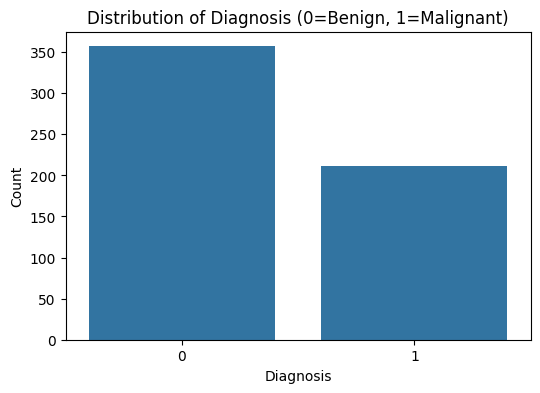

In [ ]:
# Import Libraries
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize the distribution of the target variable 'diagnosis'
plt.figure(figsize=(6, 4))
sns.countplot(x='diagnosis', data=df)
plt.title('Distribution of Diagnosis (0=Benign, 1=Malignant)')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.show()

In [ ]:
df['diagnosis'].value_counts()

,count
diagnosis,
0,357
1,212


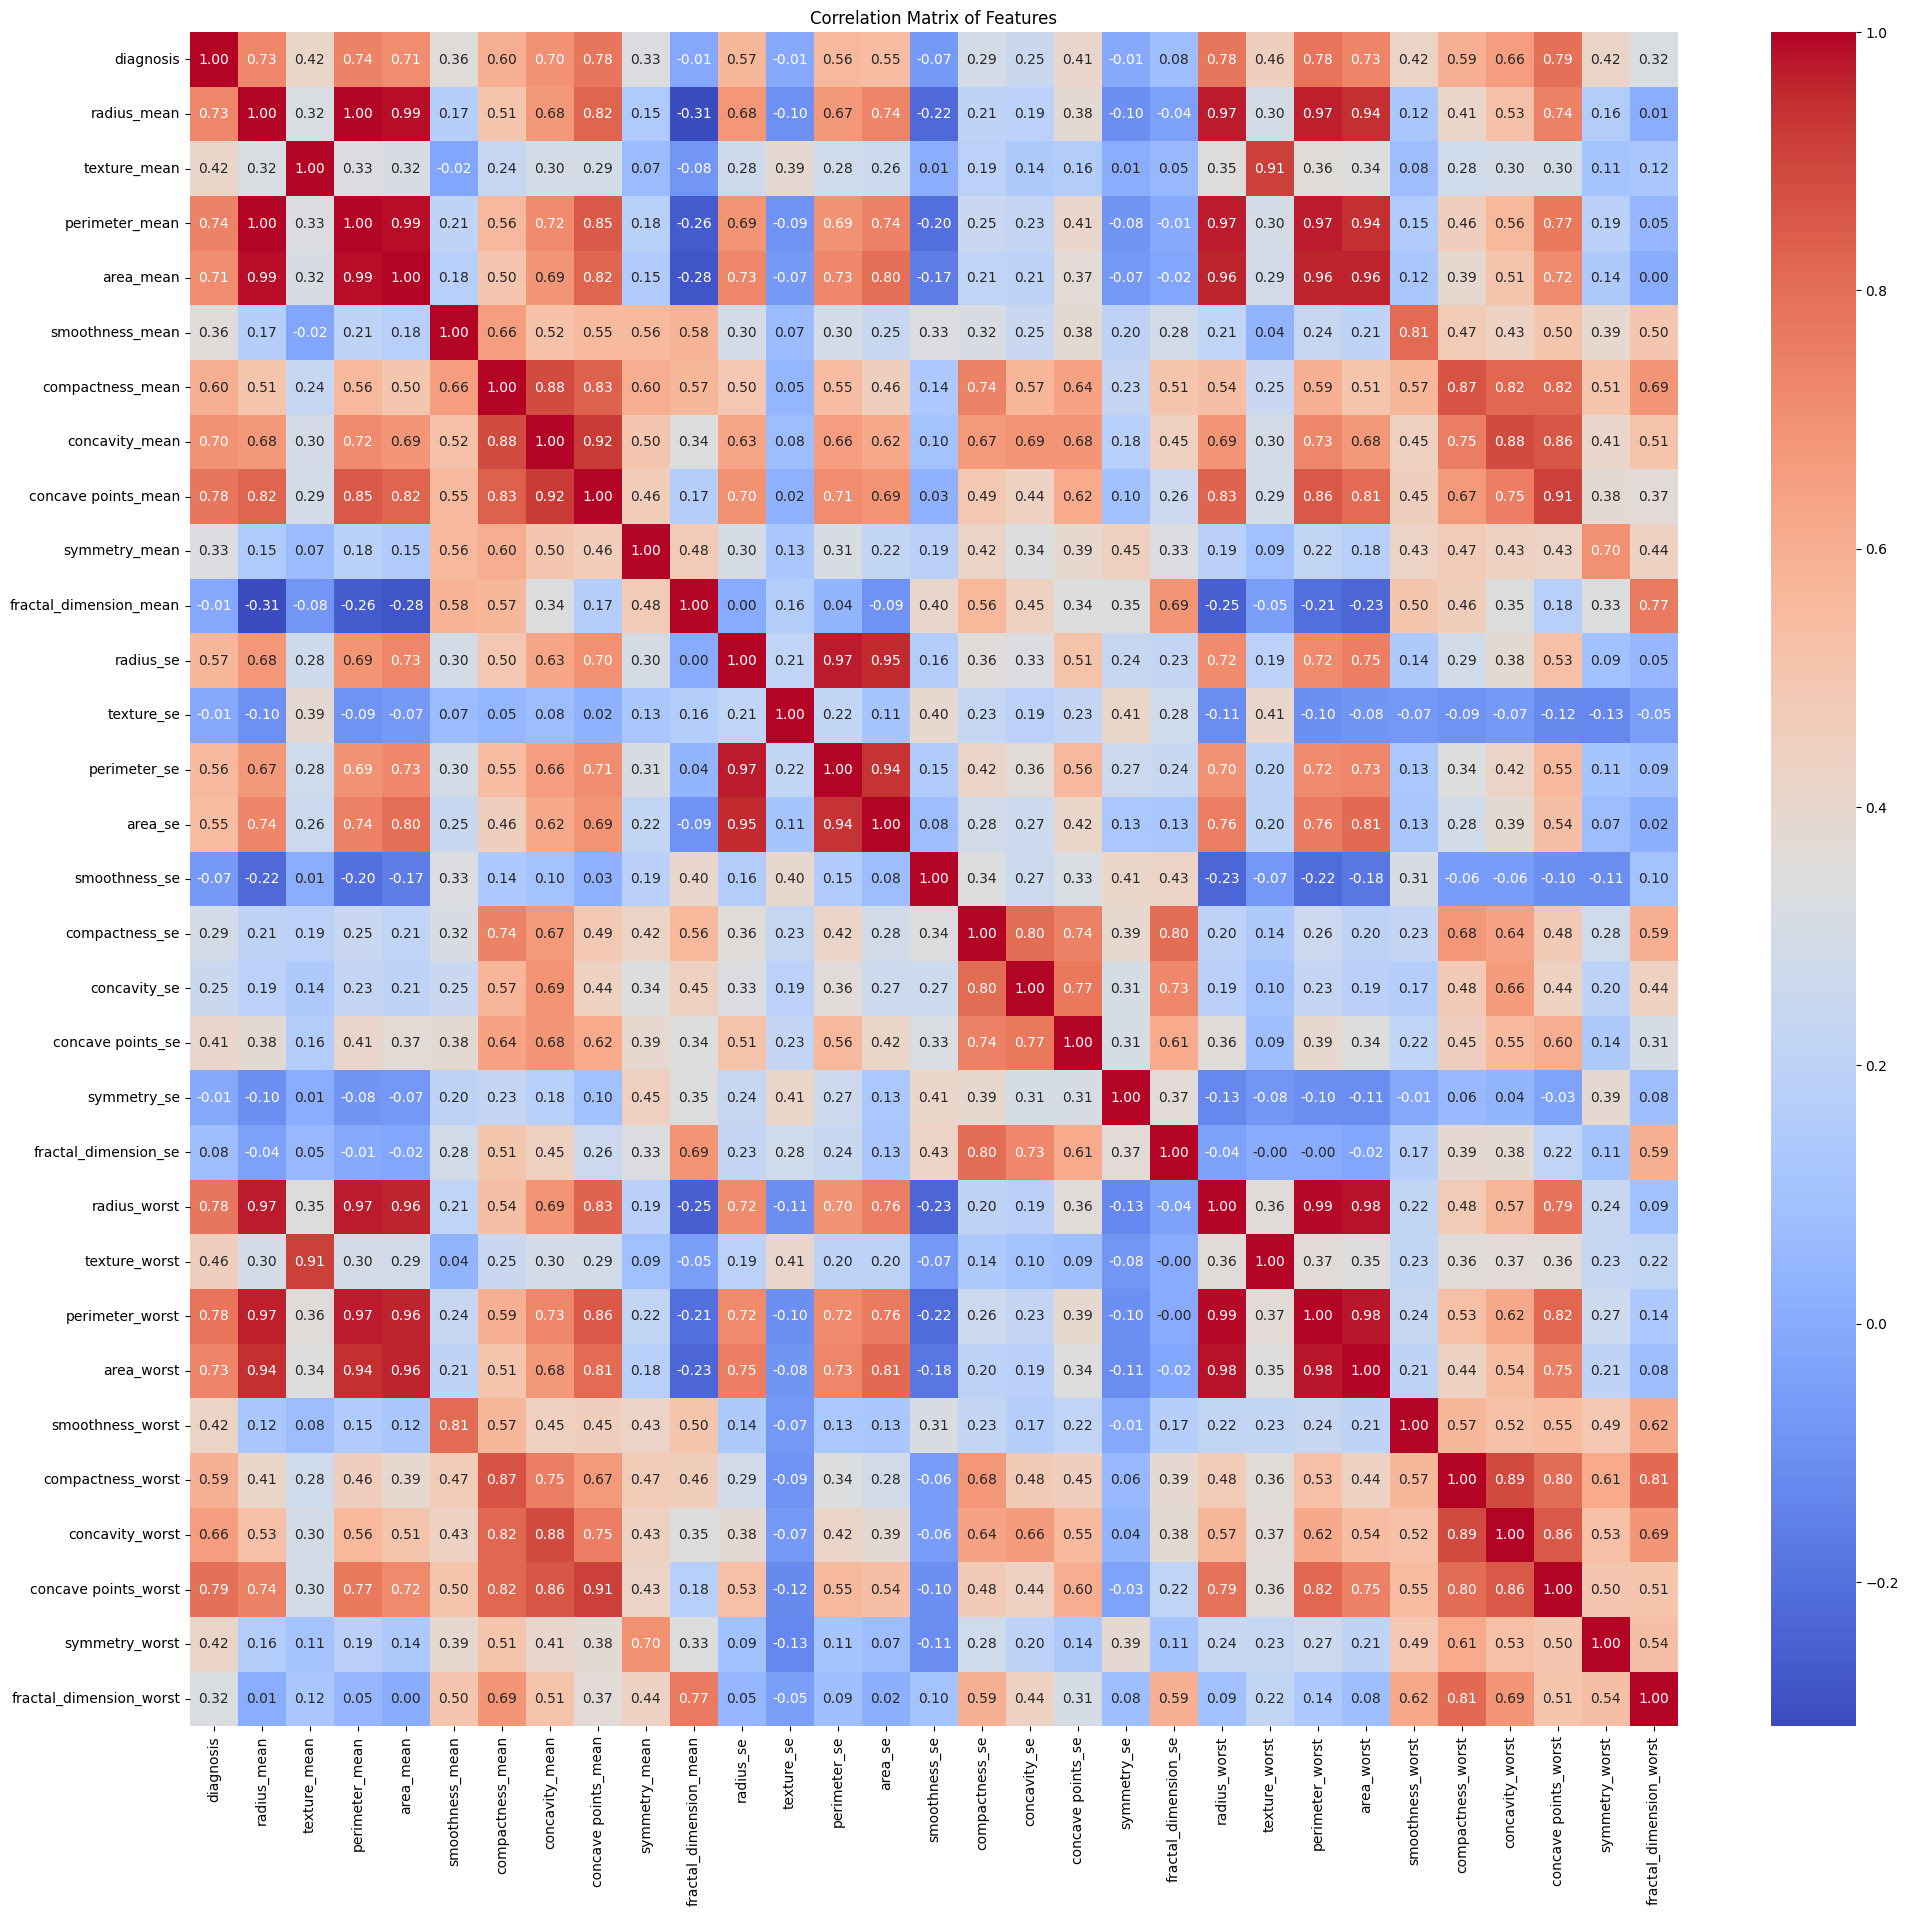

In [ ]:
# Calculate the correlation matrix
correlation_matrix = df.corr()

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(24, 22))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
plt.title('Correlation Matrix of Features')
plt.show()

Task 4 - SVM Classification Model development and Evaluation



In [ ]:
# Import Libraries
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
x = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

In [ ]:
# Split Data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
# Support Vector Machine (SVM) - Model training
svm = SVC(kernel='linear', random_state=42)
svm.fit(x_train, y_train)

SVC(kernel='linear', random_state=42)

In [ ]:
# Model prediction
y_pred_svm = svm.predict(x_test)

In [ ]:
# Evaluation
print("Support Vector Machine Classification Report:\n", classification_report(y_test, y_pred_svm))
print("Support Vector Machine Accuracy Score:", accuracy_score(y_test, y_pred_svm))

Support Vector Machine Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97        71
           1       0.97      0.91      0.94        43

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Support Vector Machine Accuracy Score: 0.956140350877193


Task 5 - SVM ROC curve

In [ ]:
from sklearn.metrics import roc_curve, auc

# ROC Curve for SVM
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm.decision_function(x_test))
roc_auc_svm = auc(fpr_svm, tpr_svm)

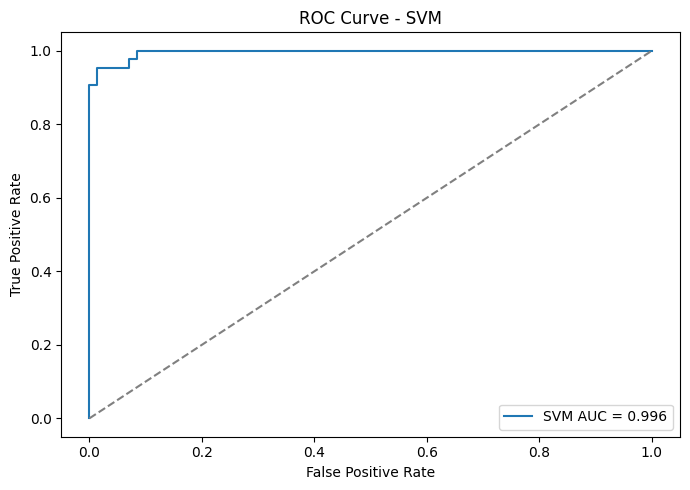

In [ ]:
plt.figure(figsize=(7,5))
plt.plot(fpr_svm, tpr_svm, label=f"SVM AUC = {roc_auc_svm:.3f}")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")
plt.legend()
plt.tight_layout()
plt.show()

Task 6 - 3D visualisation for SVM Classification Model

In [ ]:
# Import Libraries
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

In [ ]:
features_3d = ["radius_mean", "texture_mean", "perimeter_mean"]
X3 = df[features_3d]
y3 = df["diagnosis"]

In [ ]:
from sklearn.preprocessing import StandardScaler
X3_scaled = StandardScaler().fit_transform(X3)
X3_pca = PCA(n_components=3, random_state=42).fit_transform(X3_scaled)

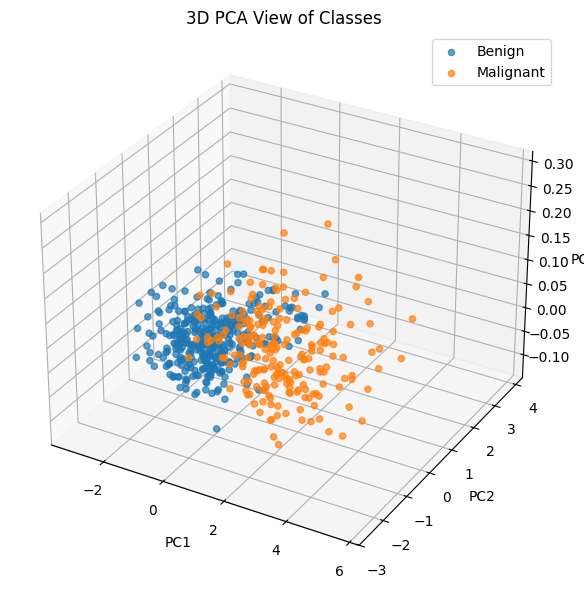

In [ ]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X3_pca[y3==0,0], X3_pca[y3==0,1], X3_pca[y3==0,2], label="Benign", alpha=0.7)
ax.scatter(X3_pca[y3==1,0], X3_pca[y3==1,1], X3_pca[y3==1,2], label="Malignant", alpha=0.7)
ax.set_title("3D PCA View of Classes")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.legend()
plt.tight_layout()
plt.show()

Task 6 - XGBoost Model Building and Parameter Tuning

In [ ]:
# Import Libraries
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

In [ ]:
xgb = XGBClassifier(objective="binary:logistic",eval_metric="logloss",random_state=42)

In [ ]:
param_grid = {"n_estimators": [50, 100, 200],"learning_rate": [0.01, 0.05, 0.1, 0.2]}
grid = GridSearchCV(xgb,param_grid,scoring="accuracy",cv=5,n_jobs=-1)

In [ ]:
grid.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     learning_rate=None, max_bin=None,
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1, 0.2],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy')

In [ ]:
print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)

Best params: {'learning_rate': 0.2, 'n_estimators': 100}
Best CV score: 0.9670329670329672


In [ ]:
best_xgb = grid.best_estimator_
y_pred_xgb = best_xgb.predict(x_test)
y_prob_xgb = best_xgb.predict_proba(x_test)[:, 1]

In [ ]:
# XGBoost Model Evaluation - Classification Report
print("XGBoost Classification Report")
print(classification_report(y_test, y_pred_xgb))
print("XGBoost accuracy:", accuracy_score(y_test, y_pred_xgb))

XGBoost Classification Report
              precision    recall  f1-score   support

           0       0.96      0.97      0.97        71
           1       0.95      0.93      0.94        43

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

XGBoost accuracy: 0.956140350877193


Task 7 - XGBoost ROC curve

In [ ]:
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
auc_xgb = auc(fpr_xgb, tpr_xgb)

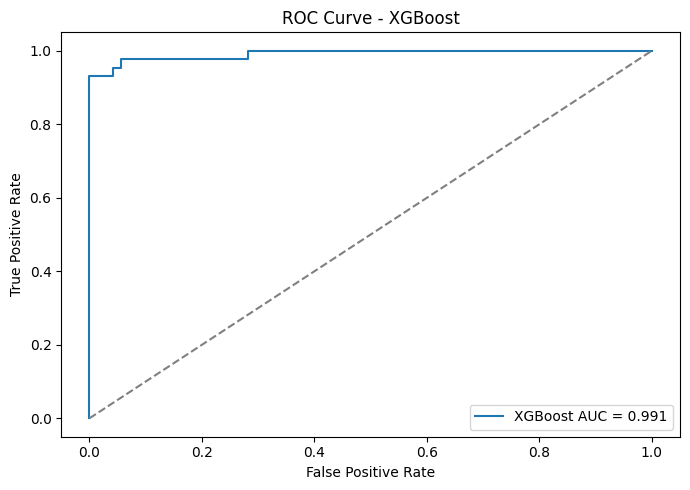

In [ ]:
plt.figure(figsize=(7,5))
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost AUC = {auc_xgb:.3f}")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.tight_layout()
plt.show()

Task 8 - XGBoost Model Tuning Visualisation (Heatmap)



In [ ]:
results = pd.DataFrame(grid.cv_results_)
pivot = results.pivot(index="param_learning_rate", columns="param_n_estimators", values="mean_test_score")

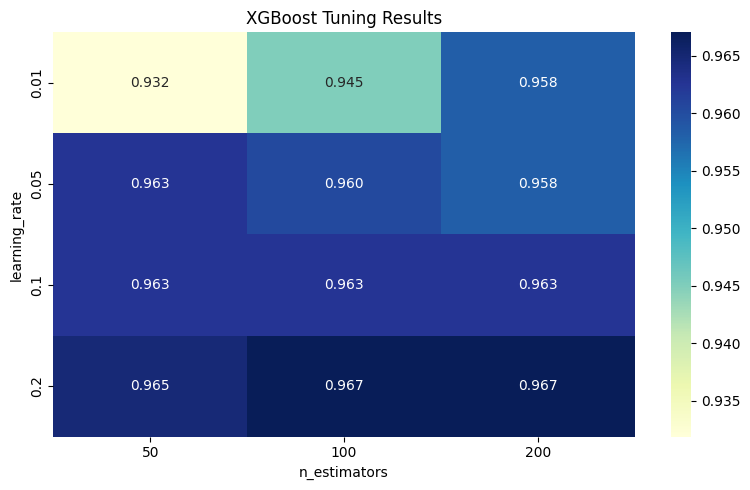

In [ ]:
plt.figure(figsize=(8,5))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("XGBoost Tuning Results")
plt.xlabel("n_estimators")
plt.ylabel("learning_rate")
plt.tight_layout()
plt.show()

Task 9 - Model Evaluation and Comparison using Confusion Matrix

In [ ]:
# Import Library
from sklearn.metrics import confusion_matrix

In [ ]:
cm_svm = confusion_matrix(y_test, y_pred_svm)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

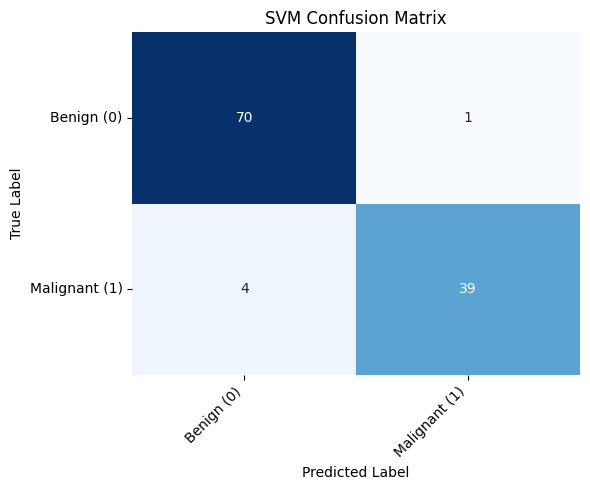

In [ ]:
# SVM Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(ticks=[0.5, 1.5], labels=['Benign (0)', 'Malignant (1)'], rotation=45, ha='right')
plt.yticks(ticks=[0.5, 1.5], labels=['Benign (0)', 'Malignant (1)'], rotation=0)
plt.tight_layout()
plt.show()

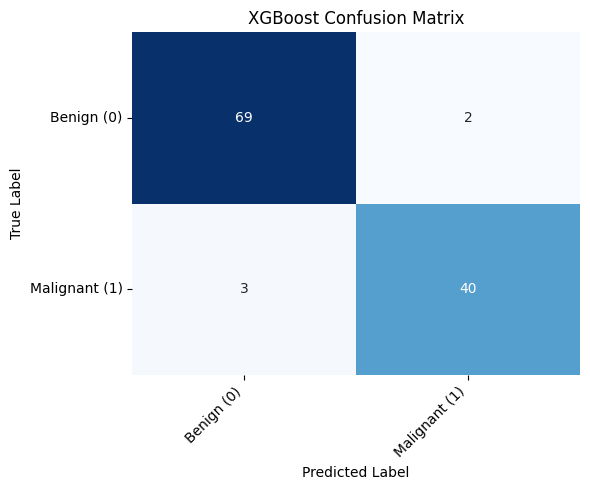

In [ ]:
# XGBoost Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(ticks=[0.5, 1.5], labels=['Benign (0)', 'Malignant (1)'], rotation=45, ha='right')
plt.yticks(ticks=[0.5, 1.5], labels=['Benign (0)', 'Malignant (1)'], rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
print("Confusion Matrix for SVM:")
print(cm_svm)
print("\nConfusion Matrix for XGBoost:")
print(cm_xgb)

Confusion Matrix for SVM:
[[70  1]
 [ 4 39]]

Confusion Matrix for XGBoost:
[[69  2]
 [ 3 40]]


In [ ]:
fnr_svm = cm_svm[1,0] / (cm_svm[1,0] + cm_svm[1,1])
fnr_xgb = cm_xgb[1,0] / (cm_xgb[1,0] + cm_xgb[1,1])

In [ ]:
# SVM vs XGBoost: Model Comparison and Key Insights
comparison = pd.DataFrame({"Model": ["SVM", "XGBoost"],"False Negative Rate": [fnr_svm, fnr_xgb]})

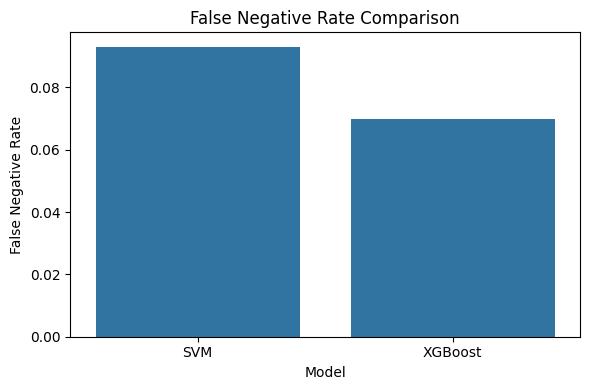

In [ ]:
plt.figure(figsize=(6,4))
sns.barplot(data=comparison, x="Model", y="False Negative Rate")
plt.title("False Negative Rate Comparison")
plt.tight_layout()
plt.show()

### Summary of Results

Both the Support Vector Machine (SVM) and XGBoost models demonstrated strong performance in classifying breast tumors as benign or malignant. Both models achieved an accuracy of approximately 95.6% on the test set.

Key findings include:
- **SVM Model**: Achieved a high accuracy of 0.956, with a False Negative Rate (FNR) of approximately 0.093. Its ROC AUC score was 0.996.
- **XGBoost Model**: Also achieved an accuracy of 0.956, but showed a slightly lower False Negative Rate (FNR) of approximately 0.070. Its ROC AUC score was 0.991.

The lower False Negative Rate of the XGBoost model is particularly significant in a medical context, as it indicates a better ability to correctly identify malignant cases, reducing the chance of missed diagnoses. While both models are highly effective, XGBoost marginally outperforms SVM in minimizing false negatives, making it a slightly preferred choice for this diagnostic task.